In [1]:
# from google.colab import drive
# drive.mount('/content/drive')


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
import pickle

In [3]:
df = pd.read_csv("placement.csv")

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


## Plan
- Preprocess -EDA - Feature Selection
- Extract Input Output Columns
- Scale the values
- Train test split
- Train the model
- Evaluate the model/model selction
- Deploy the model

Preprocess and EDA

In [6]:
df.describe()

,Unnamed: 0,cgpa,iq,placement
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,5.991000,123.580000,0.500000
std,29.011492,1.143634,39.944198,0.502519
min,0.000000,3.300000,37.000000,0.000000
25%,24.750000,5.075000,101.500000,0.000000
50%,49.500000,6.000000,127.500000,0.500000
75%,74.250000,6.900000,149.000000,1.000000
max,99.000000,8.500000,233.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
df = df.iloc[:,1:]

In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


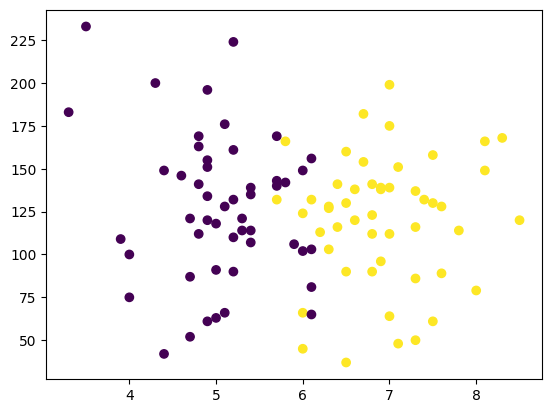

In [13]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

### Logisitic Regression
Feature Selection

cgpa and iq indepedent variable

placement depedent variable

In [38]:
X = df.iloc[:, 0:2]
Y = df.iloc[:, -1]

In [23]:
X

,cgpa
0,6.8
1,5.9
2,5.3
3,7.4
4,5.8
...,...
95,4.3
96,4.4
97,6.7
98,6.3


In [40]:
Y
# Y.shape

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [42]:
train_test_split(X, Y, test_size=0.1)

[    cgpa     iq
 52   7.0  175.0
 31   3.9  109.0
 76   4.9  155.0
 63   6.3  128.0
 21   7.1  151.0
 ..   ...    ...
 5    7.1   48.0
 69   8.5  120.0
 42   7.6   89.0
 13   6.4  116.0
 34   4.8  163.0
 
 [90 rows x 2 columns],
     cgpa     iq
 62   6.0  102.0
 11   6.9  138.0
 12   5.4  139.0
 16   5.2  224.0
 79   6.5   90.0
 26   7.0  199.0
 53   8.3  168.0
 17   3.3  183.0
 98   6.3  103.0
 92   5.2  110.0,
 52    1
 31    0
 76    0
 63    1
 21    1
      ..
 5     1
 69    1
 42    1
 13    1
 34    0
 Name: placement, Length: 90, dtype: int64,
 62    0
 11    1
 12    0
 16    0
 79    1
 26    1
 53    1
 17    0
 98    1
 92    0
 Name: placement, dtype: int64]

Train & Test Split

In [44]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.1)

In [45]:
x_train

,cgpa,iq
30,7.6,128.0
72,7.3,116.0
50,3.5,233.0
46,5.3,114.0
38,6.5,160.0
...,...,...
35,6.8,90.0
0,6.8,123.0
80,4.9,196.0
83,7.5,130.0


scaling

In [47]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_train

array([[ 1.32414575,  0.10902098],
       [ 1.06469774, -0.18314442],
       [-2.22164367,  2.66546817],
       [-0.66495563, -0.23183865],
       [ 0.37283639,  0.88812869],
       [ 0.6322844 , -0.28053288],
       [-0.57847296,  0.37683925],
       [-1.09736898, -0.28053288],
       [-0.7514383 ,  0.91247581],
       [-1.18385164, -0.88921079],
       [ 1.75655909,  1.03421139],
       [-0.92440364, -1.47354158],
       [ 0.37283639,  0.15771521],
       [ 0.28635373, -0.18314442],
       [ 0.80524974,  1.25333544],
       [ 0.89173241, -1.83874832],
       [-1.52978232,  1.86201334],
       [-0.7514383 , -0.32922712],
       [-0.31902496,  0.47422772],
       [-1.44329965,  0.62031042],
       [-0.05957695,  0.01163251],
       [ 2.10248977, -0.08575595],
       [-1.09736898,  0.42553349],
       [ 0.19987106,  0.08467386],
       [ 1.49711109, -0.23183865],
       [-0.83792097,  0.10902098],
       [ 1.67007643, -1.08398772],
       [ 1.06469774, -0.9135579 ],
       [-0.05957695,

In [48]:
x_test = scaler.transform(x_test)
x_test

array([[-1.01088631,  0.66900465],
       [-0.57847296, -0.23183865],
       [-0.7514383 , -0.81616944],
       [-1.09736898,  0.96117004],
       [-1.01088631,  0.76639311],
       [ 0.19987106, -0.49965693],
       [-1.01088631,  0.25510367],
       [ 0.45931906, -0.08575595],
       [-1.01088631, -0.08575595],
       [-0.92440364, -0.79182232]])

model training

In [58]:
# model training
clf = LogisticRegression()
clf.fit(x_train, y_train)

LogisticRegression()

Evaluate the model/model selction

In [59]:
y_pred = clf.predict(x_test)

In [63]:
accuracy_score(y_test, y_pred)

1.0

In [53]:
y_test

,placement
89,0
41,0
28,0
34,0
76,0
98,1
40,0
20,1
22,0
25,0


<Axes: >

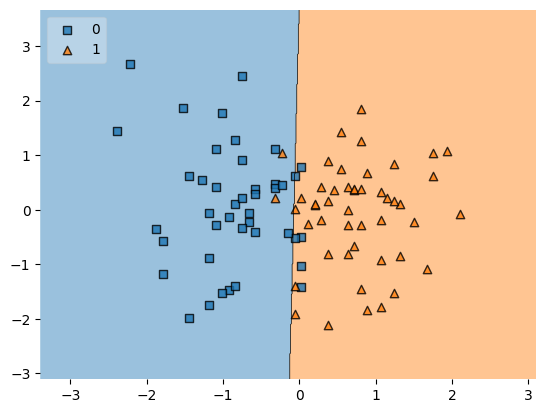

In [62]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

train as model

In [65]:
pickle.dump(clf, open('model.pkl', 'wb'))